# Study 255 -- Fear-Greed
## For the quants: band means, HAC tests, shuffled-sentiment null, sub-periods, costs

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fear_greed_index import data, strategy as st

GSPC_CACHE = data.GSPC_CACHE
HAVE_REAL = os.path.exists(GSPC_CACHE)

if HAVE_REAL:
    panel = data.real_panel(fetch=False)
    fr = st.forward_returns(panel)
    spread = st.spread_returns(fr)
    rm = st.regime_means(fr)
    print(f"Real tape loaded: {len(panel)} weeks  {panel.index[0].date()} -> {panel.index[-1].date()}")
    print(f"Forward-return rows: {len(fr)}")
else:
    panel = fr = spread = rm = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")


Real tape loaded: 768 weeks  2011-09-30 -> 2026-06-12
Forward-return rows: 767


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-12)
R = {'n_weeks': 767, 'stamp': '2011-09-30 -> 2026-06-12', 'fingerprint': '6d62af784bd5', 'uncond_ann': 14.05, 'ef_ann': 14.2, 'ef_t': 0.61, 'ef_n': 65, 'fear_ann': 6.68, 'fear_t': 0.73, 'fear_n': 183, 'neu_ann': 15.24, 'neu_t': 2.26, 'neu_n': 165, 'greed_ann': 17.23, 'greed_t': 5.33, 'greed_n': 332, 'eg_ann': 18.17, 'eg_t': 1.4, 'eg_n': 22, 'spread_bps': 1.31, 'spread_ann': 0.68, 'spread_t': 0.41, 'spread_hit': 0.056, 'spread_sr': 0.07, 'spread_ci_lo': -0.241, 'spread_ci_hi': 0.455, 'spread_frac_neg': 33, 'fear_excess_ann': 0.15, 'fear_excess_t': 0.01, 'slope_bps': 16.82, 'slope_t': 0.53, 'sub_2011_ann': 2.71, 'sub_2011_t': 1.32, 'sub_2011_n': 275, 'sub_2017_ann': 0.66, 'sub_2017_t': 0.15, 'sub_2017_n': 261, 'sub_2022_ann': -1.7, 'sub_2022_t': -0.64, 'sub_2022_n': 231, 'null_mean_bps': 1.4, 'null_std_bps': 2.64, 'real_pctile': 47.5, 'pct_long': 8.5, 'pct_flat': 88.7, 'pct_short': 2.9, 'n_trades': 41, 'trades_per_year': 2.8, 'net_ann': 0.53, 'net_t': 0.31, 'ctrl_null_bps': -5.66, 'ctrl_null_t': -1.96, 'ctrl_60_bps': 3.76, 'ctrl_60_t': 1.32, 'ctrl_120_bps': 13.18, 'ctrl_120_t': 3.85}


## Positive control: the engine recovers a planted contrarian premium

Before trusting a null result we confirm the machinery *can* see a contrarian
effect when one exists. `data.synthetic_panel(contrarian_bps=...)` plants a
forward-return tilt that is positive after low sentiment and negative after high
sentiment. With `contrarian_bps=0` the spread is a noisy zero; with a strong
premium it clears `t > 2`.

> 💡 **In plain words:** this is the smoke test. If the synthetic control didn't
> light up, a flat real result would just mean the code was broken.


In [3]:
for prem in [0.0, 60.0, 120.0]:
    d, _ = data.synthetic_panel(contrarian_bps=prem, seed=255)
    f = st.forward_returns(d)
    sc = st.summarize(st.spread_returns(f))
    print(f"premium={prem:6.1f} bps -> spread {sc['mean']*10000:+6.2f} bps/wk  HAC t={sc['tstat']:+.2f}  n={sc['n']}")
print()
print(f"Frozen: null t={R['ctrl_null_t']:+.2f} (within null band), "
      f"+120bps t={R['ctrl_120_t']:+.2f} (clears the bar). The engine works.")


premium=   0.0 bps -> spread  -5.66 bps/wk  HAC t=-1.96  n=599


premium=  60.0 bps -> spread  +3.76 bps/wk  HAC t=+1.32  n=599
premium= 120.0 bps -> spread +13.18 bps/wk  HAC t=+3.85  n=599

Frozen: null t=-1.96 (within null band), +120bps t=+3.85 (clears the bar). The engine works.


## Band conditional means with HAC t-stats

In [4]:
bands = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
if HAVE_REAL:
    print("=== Forward weekly return by Fear & Greed band ===")
    print(f"Unconditional: {fr['fwd_ret'].mean()*52*100:+.2f}%/yr\n")
    for b in bands:
        row = rm.loc[b]
        print(f"  {b:14s} n={int(row['n']):4d}  {row['mean_ann']*100:+7.2f}%/yr  HAC t={row['tstat']:+5.2f}  hit={row['hit']:.3f}")
else:
    print("Frozen band table:")
    for b, a, t, n in [("Extreme Fear", R['ef_ann'], R['ef_t'], R['ef_n']),
                       ("Fear", R['fear_ann'], R['fear_t'], R['fear_n']),
                       ("Neutral", R['neu_ann'], R['neu_t'], R['neu_n']),
                       ("Greed", R['greed_ann'], R['greed_t'], R['greed_n']),
                       ("Extreme Greed", R['eg_ann'], R['eg_t'], R['eg_n'])]:
        print(f"  {b:14s} n={n:4d}  {a:+7.2f}%/yr  HAC t={t:+5.2f}")
print("\nThe contrarian claim needs Extreme Fear >> Extreme Greed. We observe the opposite tilt.")


=== Forward weekly return by Fear & Greed band ===
Unconditional: +14.05%/yr

  Extreme Fear   n=  65   +14.20%/yr  HAC t=+0.61  hit=0.523
  Fear           n= 183    +6.68%/yr  HAC t=+0.73  hit=0.541
  Neutral        n= 165   +15.24%/yr  HAC t=+2.26  hit=0.618
  Greed          n= 332   +17.23%/yr  HAC t=+5.33  hit=0.617
  Extreme Greed  n=  22   +18.17%/yr  HAC t=+1.40  hit=0.591

The contrarian claim needs Extreme Fear >> Extreme Greed. We observe the opposite tilt.


## The decisive series: the contrarian fear-minus-greed spread

In [5]:
if HAVE_REAL:
    s_sp = st.summarize(spread); s_a = st.annualise_weekly(s_sp)
    fe = st.long_only_fear_excess(fr); s_fe = st.summarize(fe)
    sl = st.sentiment_slope(fr)
    print("=== Primary spec: long Extreme Fear, short Extreme Greed, 1-week hold ===")
    print(f"Spread: {s_sp['mean']*10000:+.2f} bps/wk = {s_sp['mean']*52*100:+.2f}%/yr  HAC t={s_sp['tstat']:+.2f}  hit={s_sp['hit_rate']:.3f}  SR(ann)={s_a.get('sharpe_ann', float('nan')):+.2f}")
    print(f"Long-only fear excess (price-only): {s_fe['mean']*52*100:+.2f}%/yr  HAC t={s_fe['tstat']:+.2f}  n={s_fe['n']}")
    print(f"Linear sentiment slope: {sl['slope']*10000:+.2f} bps per 50 F&G pts  HAC t={sl['tstat']:+.2f}  (wrong sign for contrarian)")
    try:
        from quantlab.stats import sharpe_ci_bootstrap
        ci = sharpe_ci_bootstrap(spread, n_boot=2000, periods_per_year=52, seed=255)
        print(f"\nBootstrap spread Sharpe 95% CI: [{ci['ci_low']:+.3f}, {ci['ci_high']:+.3f}]  ({ci['frac_negative']*100:.0f}% negative)")
    except ImportError:
        print(f"\n[quantlab unavailable -- frozen CI: [{R['spread_ci_lo']:+.3f}, {R['spread_ci_hi']:+.3f}]]")
else:
    print(f"Frozen spread: {R['spread_ann']:+.2f}%/yr  HAC t={R['spread_t']:+.2f}  hit={R['spread_hit']:.3f}")
    print(f"Bootstrap Sharpe CI: [{R['spread_ci_lo']:+.3f}, {R['spread_ci_hi']:+.3f}]  ({R['spread_frac_neg']}% negative)")
    print(f"Long-only fear excess: {R['fear_excess_ann']:+.2f}%/yr  HAC t={R['fear_excess_t']:+.2f}")
    print(f"Sentiment slope: {R['slope_bps']:+.2f} bps/50pts  HAC t={R['slope_t']:+.2f}")
print("\n> The spread HAC t is nowhere near the t>=2 inference bar. Bootstrap CI straddles zero.")


=== Primary spec: long Extreme Fear, short Extreme Greed, 1-week hold ===
Spread: +1.31 bps/wk = +0.68%/yr  HAC t=+0.41  hit=0.056  SR(ann)=+0.07
Long-only fear excess (price-only): +0.15%/yr  HAC t=+0.01  n=65
Linear sentiment slope: +16.82 bps per 50 F&G pts  HAC t=+0.53  (wrong sign for contrarian)



Bootstrap spread Sharpe 95% CI: [-0.241, +0.455]  (33% negative)

> The spread HAC t is nowhere near the t>=2 inference bar. Bootstrap CI straddles zero.


## Shuffled-sentiment null: real signal vs random relabelling

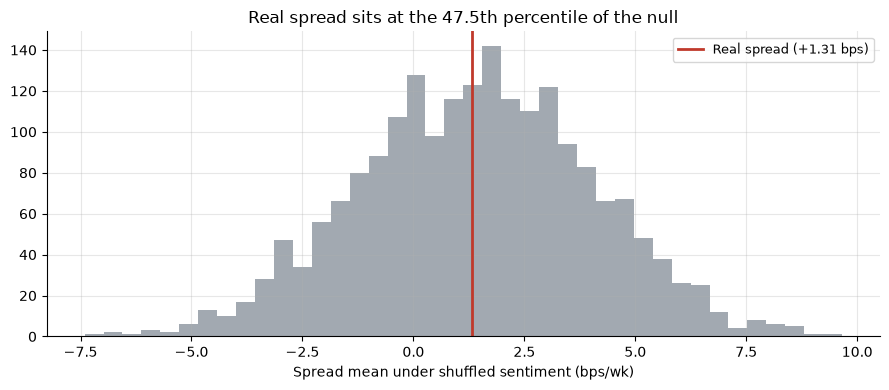

Null mean +1.40 bps (std 2.64); real at 47.5th pctile.
Permuting the sentiment column gives the SAME result on average -> no genuine timing information.


In [6]:
if HAVE_REAL:
    null = st.random_timing_null(fr, n_draws=2000, seed=255)
    real_mean = spread.mean()
    pctile = (null < real_mean).mean() * 100
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(null.values * 10000, bins=40, color=GREY, alpha=0.8)
    ax.axvline(real_mean * 10000, color=RED, lw=2.0, label=f"Real spread ({real_mean*10000:+.2f} bps)")
    ax.set_xlabel("Spread mean under shuffled sentiment (bps/wk)")
    ax.set_title(f"Real spread sits at the {pctile:.1f}th percentile of the null")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("../docs/null_hist.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Null mean {null.mean()*10000:+.2f} bps (std {null.std()*10000:.2f}); real at {pctile:.1f}th pctile.")
else:
    print(f"Frozen: null mean {R['null_mean_bps']:+.2f} bps (std {R['null_std_bps']:.2f}); real at {R['real_pctile']:.1f}th pctile.")
print("Permuting the sentiment column gives the SAME result on average -> no genuine timing information.")


## Sub-period decay -- no era rescues it

  2011-2016: +2.71%/yr  HAC t=+1.32  n=275
  2017-2021: +0.66%/yr  HAC t=+0.15  n=261
  2022-2026: -1.70%/yr  HAC t=-0.64  n=231


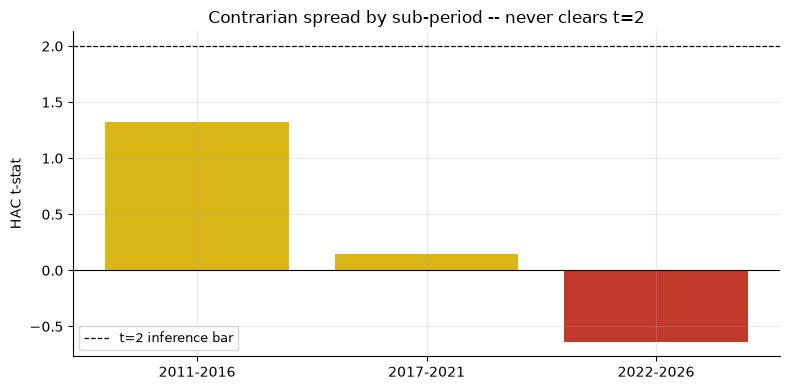

In [7]:
periods = [("2011-2016", "2011", "2016"), ("2017-2021", "2017", "2021"), ("2022-2026", "2022", "2026")]
if HAVE_REAL:
    rows = []
    for label, a, b in periods:
        s = st.summarize(spread[a:b])
        rows.append({"period": label, "ann": s["mean"]*52*100, "t": s["tstat"], "n": s["n"]})
        print(f"  {label}: {s['mean']*52*100:+.2f}%/yr  HAC t={s['tstat']:+.2f}  n={s['n']}")
    sts = pd.DataFrame(rows)
else:
    sts = pd.DataFrame([
        {"period": "2011-2016", "ann": R["sub_2011_ann"], "t": R["sub_2011_t"], "n": R["sub_2011_n"]},
        {"period": "2017-2021", "ann": R["sub_2017_ann"], "t": R["sub_2017_t"], "n": R["sub_2017_n"]},
        {"period": "2022-2026", "ann": R["sub_2022_ann"], "t": R["sub_2022_t"], "n": R["sub_2022_n"]},
    ])
    for _, r in sts.iterrows():
        print(f"  {r['period']}: {r['ann']:+.2f}%/yr  HAC t={r['t']:+.2f}  n={int(r['n'])}")

fig, ax = plt.subplots(figsize=(8, 4))
colors_sub = [GREEN if t >= 2 else RED if t < 0 else AMBER for t in sts["t"]]
ax.bar(sts["period"], sts["t"], color=colors_sub)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t=2 inference bar")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("HAC t-stat")
ax.set_title("Contrarian spread by sub-period -- never clears t=2")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Turnover and costs -- there is no edge to erode

In [8]:
if HAVE_REAL:
    ts = st.turnover_stats(fr)
    net = st.net_spread_returns(fr, one_way_bps=5.0, borrow_bps_ann=50.0)
    s_net = st.summarize(net)
    print(f"States: long {ts['pct_long']:.1%}, flat {ts['pct_flat']:.1%}, short {ts['pct_short']:.1%}")
    print(f"Trades: {ts['n_trades']} ({ts['trades_per_year']:.1f}/yr) -- the overlay barely trades")
    print(f"Net spread @5bps one-way + 50bps/yr borrow: {s_net['mean']*52*100:+.2f}%/yr  HAC t={s_net['tstat']:+.2f}")
else:
    print(f"States: long {R['pct_long']:.1f}%, flat {R['pct_flat']:.1f}%, short {R['pct_short']:.1f}%")
    print(f"Trades: {R['n_trades']} ({R['trades_per_year']:.1f}/yr)")
    print(f"Net spread @5bps + 50bps/yr borrow: {R['net_ann']:+.2f}%/yr  HAC t={R['net_t']:+.2f}")
print("\nCosts are tiny because Extreme Fear/Greed are rare (~11% of weeks). The verdict is")
print("not a cost death -- there is simply no gross signal (gross t = 0.41).")


States: long 8.5%, flat 88.7%, short 2.9%
Trades: 41 (2.8/yr) -- the overlay barely trades
Net spread @5bps one-way + 50bps/yr borrow: +0.53%/yr  HAC t=+0.31

Costs are tiny because Extreme Fear/Greed are rare (~11% of weeks). The verdict is
not a cost death -- there is simply no gross signal (gross t = 0.41).


## Verdict

In [9]:
print("=== Study 255 -- Fear-Greed ===")
print()
print(f"Signal: NONE")
print(f"  Contrarian spread HAC t = {R['spread_t']:+.2f}  (bar is t>=2)")
print(f"  Bootstrap Sharpe CI [{R['spread_ci_lo']:+.2f}, {R['spread_ci_hi']:+.2f}], {R['spread_frac_neg']}% negative -> straddles zero")
print(f"  Real spread at {R['real_pctile']:.1f}th percentile of shuffled-sentiment null")
print(f"  Band pattern is the OPPOSITE of the claim (returns rise with greed: bull-trend artefact)")
print()
print(f"Tradability: MIRAGE")
print(f"  No gross edge to trade; overlay flat {R['pct_flat']:.0f}% of weeks; even gross t = {R['spread_t']:+.2f}")
print()
print("Data caveat: curated-proxy Fear & Greed series; ^GSPC price-only (dividend-neutral spread unaffected)")
print()
print("Bottom line: None/Mirage -- a great thermometer, a useless clock.")


=== Study 255 -- Fear-Greed ===

Signal: NONE
  Contrarian spread HAC t = +0.41  (bar is t>=2)
  Bootstrap Sharpe CI [-0.24, +0.46], 33% negative -> straddles zero
  Real spread at 47.5th percentile of shuffled-sentiment null
  Band pattern is the OPPOSITE of the claim (returns rise with greed: bull-trend artefact)

Tradability: MIRAGE
  No gross edge to trade; overlay flat 89% of weeks; even gross t = +0.41

Data caveat: curated-proxy Fear & Greed series; ^GSPC price-only (dividend-neutral spread unaffected)

Bottom line: None/Mirage -- a great thermometer, a useless clock.
